# BugReduction

In [ ]:
%%writefile BugReduction.c

#include <omp.h>
#include <stdio.h>
#include <stdlib.h>

/*float dotprod(float * a, float * b, size_t N)
{

    int i, tid;
    // float sum;

    tid = omp_get_thread_num();

    #pragma omp for reduction(+:sum)
    for (i = 0; i < N; ++i)
    {
        sum += a[i] * b[i];
        printf("tid = %d i = %d\n", tid, i);
    }

    return sum;
}*/

int main (int argc, char *argv[])
{
    omp_set_dynamic(0);
    omp_set_num_threads(5);
    const size_t N = 100;
    int i;
    float sum;
    float a[N], b[N];


    for (i = 0; i < N; ++i)
    {
        a[i] = b[i] = (double)i;
    }

    sum = 0.0;

    #pragma omp parallel shared(sum)
    {
        int i, tid;
        tid = omp_get_thread_num();

        #pragma omp for reduction(+:sum)
        for (i = 0; i < N; ++i)
        {
            sum += a[i] * b[i];
            printf("tid = %d i = %d\n", tid, i);
        }
    }
    printf("Sum = %f\n",sum);

    return 0;
}

Overwriting BugReduction.c


In [ ]:
!gcc BugReduction.c -o bug.exe -fopenmp

In [ ]:
!./bug.exe

tid = 0 i = 0
tid = 0 i = 1
tid = 0 i = 2
tid = 0 i = 3
tid = 0 i = 4
tid = 0 i = 5
tid = 0 i = 6
tid = 0 i = 7
tid = 0 i = 8
tid = 0 i = 9
tid = 0 i = 10
tid = 0 i = 11
tid = 0 i = 12
tid = 0 i = 13
tid = 0 i = 14
tid = 0 i = 15
tid = 0 i = 16
tid = 0 i = 17
tid = 0 i = 18
tid = 0 i = 19
tid = 4 i = 80
tid = 4 i = 81
tid = 4 i = 82
tid = 4 i = 83
tid = 4 i = 84
tid = 4 i = 85
tid = 4 i = 86
tid = 4 i = 87
tid = 4 i = 88
tid = 4 i = 89
tid = 4 i = 90
tid = 4 i = 91
tid = 4 i = 92
tid = 4 i = 93
tid = 4 i = 94
tid = 4 i = 95
tid = 4 i = 96
tid = 4 i = 97
tid = 4 i = 98
tid = 4 i = 99
tid = 3 i = 60
tid = 3 i = 61
tid = 3 i = 62
tid = 3 i = 63
tid = 3 i = 64
tid = 3 i = 65
tid = 3 i = 66
tid = 3 i = 67
tid = 3 i = 68
tid = 3 i = 69
tid = 3 i = 70
tid = 3 i = 71
tid = 3 i = 72
tid = 3 i = 73
tid = 3 i = 74
tid = 3 i = 75
tid = 3 i = 76
tid = 3 i = 77
tid = 3 i = 78
tid = 3 i = 79
tid = 1 i = 20
tid = 1 i = 21
tid = 1 i = 22
tid = 1 i = 23
tid = 1 i = 24
tid = 1 i = 25
tid = 1 i = 26
tid =

# BugParFor

In [ ]:
%%writefile BugParFor.c
#include <omp.h>
#include <stdio.h>
#include <stdlib.h>

int main (int argc, char *argv[])
{
    const size_t N = 100;
    const size_t chunk = 3;

    int i, tid;
    float a[N], b[N], c[N];

    #pragma omp parallel for
    for (i = 0; i < N; ++i)
    {
        a[i] = b[i] = (float)i;
    }

    #pragma omp parallel shared(a,b,c,chunk) private(i,tid)
    {
        tid = omp_get_thread_num();

        #pragma omp for schedule(static,chunk)
        for (i = 0; i < N; ++i)
        {
            c[i] = a[i] + b[i];
            printf("tid = %d, c[%d] = %f\n", tid, i, c[i]);
        }
    }

    return 0;
}


Overwriting BugParFor.c


In [ ]:
!gcc BugParFor.c -o bug2.exe -fopenmp

In [ ]:
!./bug2.exe

tid = 0, c[0] = 0.000000
tid = 0, c[1] = 2.000000
tid = 0, c[2] = 4.000000
tid = 0, c[6] = 12.000000
tid = 0, c[7] = 14.000000
tid = 0, c[8] = 16.000000
tid = 0, c[12] = 24.000000
tid = 0, c[13] = 26.000000
tid = 0, c[14] = 28.000000
tid = 0, c[18] = 36.000000
tid = 0, c[19] = 38.000000
tid = 0, c[20] = 40.000000
tid = 0, c[24] = 48.000000
tid = 0, c[25] = 50.000000
tid = 0, c[26] = 52.000000
tid = 0, c[30] = 60.000000
tid = 0, c[31] = 62.000000
tid = 0, c[32] = 64.000000
tid = 0, c[36] = 72.000000
tid = 0, c[37] = 74.000000
tid = 0, c[38] = 76.000000
tid = 0, c[42] = 84.000000
tid = 0, c[43] = 86.000000
tid = 0, c[44] = 88.000000
tid = 0, c[48] = 96.000000
tid = 0, c[49] = 98.000000
tid = 0, c[50] = 100.000000
tid = 0, c[54] = 108.000000
tid = 0, c[55] = 110.000000
tid = 0, c[56] = 112.000000
tid = 0, c[60] = 120.000000
tid = 0, c[61] = 122.000000
tid = 0, c[62] = 124.000000
tid = 0, c[66] = 132.000000
tid = 0, c[67] = 134.000000
tid = 0, c[68] = 136.000000
tid = 0, c[72] = 144.000000

# Pi

In [ ]:
%%writefile Pi.c
#include <stdio.h>
#include <omp.h>

int main()
{
    const size_t N = 100000;
    double step;

    double x, pi, sum = 0.;

    step = 1. / (double)N;

    #pragma omp parallel for reduction(+:sum) private(x)
    for (int i = 0; i < N; ++i)
    {
        x = (i + 0.5) * step;
        sum += 4.0 / (1. + x * x);
    }

    pi = step * sum;

    printf("pi = %.16f\n", pi);

    return 0;
}

Overwriting Pi.c


In [ ]:
!gcc Pi.c -o pi.exe -fopenmp

In [ ]:
!./pi.exe

pi = 3.1415926535981464


# Car

In [28]:
%%writefile car.cpp
#include <fstream>
#include <iostream>
#include <stdlib.h>
#include <string>
#include <thread>
#include <omp.h>

#define RGB_COMPONENT_COLOR 255

static const auto THREADS = std::thread::hardware_concurrency();

struct PPMPixel {
  int red;
  int green;
  int blue;
};

typedef struct {
  int x, y, all;
  PPMPixel *data;
} PPMImage;

void readPPM(const char *filename, PPMImage &img){
    std::ifstream file(filename);
    if (file) {
        std::string s;
        int rgb_comp_color;
        file >> s;
        if (s != "P3") {
            std::cout << "error in format" << std::endl;
            exit(9);
        }
        file >> img.x >> img.y;
        file >> rgb_comp_color;
        img.all = img.x * img.y;
        std::cout << s << std::endl;
        std::cout << "x=" << img.x << " y=" << img.y << " all=" << img.all
                  << std::endl;
        img.data = new PPMPixel[img.all];
        for (int i = 0; i < img.all; i++) {
            file >> img.data[i].red >> img.data[i].green >> img.data[i].blue;
        }
    } else {
        std::cout << "the file:" << filename << "was not found" << std::endl;
    }
    file.close();
}

void writePPM(const char *filename, PPMImage &img) {
    std::ofstream file(filename, std::ofstream::out);
    file << "P3" << std::endl;
    file << img.x << " " << img.y << " " << std::endl;
    file << RGB_COMPONENT_COLOR << std::endl;

    for (int i = 0; i < img.all; i++) {
        file << img.data[i].red << " " << img.data[i].green << " "
             << img.data[i].blue << (((i + 1) % img.x == 0) ? "\n" : " ");
    }
    file.close();
}

int main(int argc, char *argv[]) {
    PPMImage image;
    readPPM("car.ppm", image);
    PPMPixel *last_col = new PPMPixel[image.y];
    double start;
    double end;
    start = omp_get_wtime();
    for (int c = 0; c < 150; c++){
        #pragma omp parallel for shared(last_col, image)
        for (int i = 0; i < image.y; i++){
            last_col[i] = image.data[i*image.x + image.x - 1];
        }
        #pragma omp parallel for shared(image, last_col)
        for (int i = image.all - 1; i >= 0; i--){
            if (i % image.x != 0){
                //std::cout << "if " << i << std::endl;
                image.data[i] = image.data[i - 1];
            }
            else {
                //std::cout << "else " << i << std::endl;
                image.data[i] = last_col[i/image.x];
            }
        }
        //if (c % 10 == 0){
          //  writePPM("new_car.ppm", image);
        //}
    }
    writePPM("new_car.ppm", image);
    end = omp_get_wtime();
    printf("Work took %f seconds\n", end - start);
    return 0;
}

Overwriting car.cpp


In [29]:
!g++ car.cpp -o car.exe -fopenmp

Let's compare the performance time with different frequency of saving the file.
1. If we save only once the file, then the performance time takes only 0.099 sec.
2. If we save the file every 10th iteration, then the performance time increases to 0.309 sec
2. If we save the file every iteration, then it takes almost 3 sec.

saving once

In [30]:
!./car.exe

P3
x=303 y=166 all=50298
Work took 0.055092 seconds


saving every 10th iteration

In [ ]:
!./car.exe

P3
x=303 y=166 all=50298
Work took 0.309175 seconds


saving every iteration

In [ ]:
!./car.exe

P3
x=303 y=166 all=50298
Work took 2.972530 seconds


In [31]:
from PIL import Image

image_path = "car.ppm"
image = Image.open(image_path)
image2 = Image.open("new_car.ppm")
image.show()

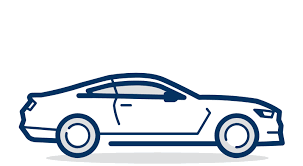

In [32]:
image

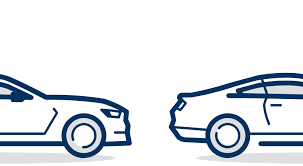

In [33]:
image2

# Axisb

In [ ]:
%%writefile axisb.cpp
#include <iostream>
#include <omp.h>
#include <cmath>
#include <random>

using namespace std;

const int n = 10;

double ** create_m() {
    double ** M = new double * [n];
    for (int i = 0; i < n; ++i) {
        M[i] = new double [n];
        double sum = 0;
        for (int j = 0; j < n; ++j){
            M[i][j] = -1. + (double)rand() / RAND_MAX * 2.;
            if (i != j){
                sum += abs(M[i][j]);
            }
        }
        if (abs(M[i][i]) < sum){
            M[i][i] = sum + 0.1 + (double)rand() / RAND_MAX * 0.9;
        }
    }
    return M;
}

double* create_b(){
    double* b = new double[n];
    for (int i = 0; i < n; ++i){
        b[i] = -1. + (double)rand() / RAND_MAX * 2.;
    }
    return b;
}

double* multiply(double** m, double* x) {
    double* res = new double[n];
    for ( size_t i = 0; i < n; ++i ) {
        res[i] = 0;
        for ( size_t j = 0; j < n; ++j ) {
            res[i] += m[i][j]*x[j];
        }
    }
    return res;
}

int main()
{
    omp_set_dynamic(0);
    omp_set_num_threads(2);

    double** m = create_m();
    double* b = create_b();

    double* x = new double[n];
    double* x0 = new double[n];

    #pragma omp parallel for shared(x0)
    for (int i = 0; i < n; ++i){
        x0[i] = 1;
    }

    for (int it = 0; it < 100; ++it) {
        #pragma omp parallel shared(x0, m, x, b)
        {
            #pragma omp for
            for (int i = 0; i < n; i++) {
                double sum = 0;
                for (int j = 0; j < n; j++){
                    if (j != i) {
                        #pragma omp critical
                        sum += x0[j] * m[i][j];
                    }
                }
                x[i] = (b[i] - sum) / m[i][i];
            }
            #pragma omp for
            for (int i = 0; i < n; i++) {
                x0[i] = x[i];
            }
        }
    }

    double* b2 = multiply(m,x);

    for (int i = 0; i < n; ++i){
        double d = b2[i] - b[i];
        //cout << d << " ";
    }
    return 0;
}

Overwriting axisb.cpp


In [ ]:
!g++ axisb.cpp -o ax.exe -fopenmp

In [ ]:
!./ax.exe

# LeastSquares

In [ ]:
%%writefile leastsquares.cpp
#include <iostream>
#include <omp.h>
#include <random>

using namespace std;

double* make_y(double** x, unsigned int const n, double b0[]){
    double* y = new double[n];
    const double mean = 0.0;
    const double stddev = 0.1;
    std::default_random_engine generator;
    std::normal_distribution<double> dist(mean, stddev);
    for (int i = 0; i < n; ++i) {
        y[i] = b0[1]*x[1][i] + b0[0] + dist(generator);
    }
    return y;
}

int main(){
    unsigned int const n = 10;
    double** x = new double*[2];
    for (int i = 0; i < 2; ++i){
        x[i] = new double[n];
    }
    for (int i = 0; i < n; ++i){
        x[0][i] = 1;
        x[1][i] = i;
    }
    double b0[2] {3,4};
    double* y = make_y(x, n, b0);
    double b[2] {};
    double alpha = 0.001;
    int const max_it = 10000;
    for (int it = 0; it < max_it; ++it){
        #pragma omp parallel for shared(y, b, x) schedule(static)
        for (int j = 0; j < 2; ++j){
            double dif = 0;
            for (int i = 0; i < n; ++i){
                dif += (y[i] - b[0] - b[1]*x[1][i])*x[j][i];
            }
            b[j] += alpha*dif;
        }
    }
    cout << "Initial coefficients: " << b0[0] << ", " << b0[1] << endl;
    cout << "Calculated coefficients: " << b[0] << ", " << b[1] << endl;
    return 0;
}

Overwriting leastsquares.cpp


In [ ]:
!g++ leastsquares.cpp -o ls.o -fopenmp

In [ ]:
!./ls.o

Initial coefficients: 3, 4
Calculated coefficients: 2.96149, 4.00711
